# Apoio a Diagnóstico por Imagem com Redes Neurais (Exemplo Didático)

**1. Contexto e aviso importante**

Hospitais e clínicas vêm estudando o uso de visão computacional para **triagem inicial** de exames de imagem — por exemplo, identificar regiões com padrão visual suspeito em uma radiografia ou tomografia, ajudando o radiologista a **priorizar** quais exames revisar primeiro. A decisão final de diagnóstico é **sempre humana**: o modelo apenas sinaliza casos para revisão prioritária.

> ## AVISO: este notebook é 100% DIDÁTICO
>
> - As "imagens" usadas aqui são **totalmente sintéticas**, geradas em Python com `numpy` — não são exames médicos reais.
> - O problema foi **simplificado ao extremo** para fins de ensino (MBA em IA).
> - **Isto NÃO é um sistema de diagnóstico médico real e NÃO deve ser usado como tal**, nem como base para decisões clínicas.
> - O objetivo é apenas ilustrar, de forma simples, como uma rede neural convolucional (CNN) pode aprender a distinguir padrões visuais em imagens — e por que isso é relevante para o contexto de apoio à triagem em saúde.

Neste exemplo, vamos:
1. Gerar um conjunto de "imagens" sintéticas em escala de cinza, divididas em duas classes: `normal` e `com padrão suspeito`;
2. Comparar uma regra simples (baseline) com uma CNN pequena treinada do zero;
3. Focar a comparação na métrica de **recall (sensibilidade)**, que é a mais crítica em triagem de saúde — deixar passar um caso suspeito (falso negativo) é o erro mais caro.

**Limitações deste notebook**

Complementando o aviso acima, vale detalhar melhor as limitações técnicas deste exercício:

- As "imagens" usadas aqui são padrões numéricos simples gerados com `numpy` (fundo uniforme + ruído gaussiano + uma mancha circular) — não são pixels de exames reais como raio-X, tomografia ou ressonância. Um sistema real de apoio a diagnóstico por imagem lida com texturas, artefatos de aquisição e variabilidade anatômica muito mais complexos, e exigiria validação clínica rigorosa, aprovação regulatória (ex: ANVISA, FDA) e datasets muito maiores e mais diversos (múltiplos equipamentos, populações e protocolos de captura) do que as 700 imagens sintéticas geradas aqui.
- Este notebook **nunca** deve ser usado como base para decisões clínicas reais — ele serve apenas para ensinar a mecânica de treinamento e avaliação de uma CNN de classificação.
- A CNN usada é minúscula (duas camadas convolucionais, ~3,6 mil parâmetros) e foi treinada com poucas centenas de imagens simuladas — muito abaixo da escala e complexidade de modelos usados em produtos reais de diagnóstico assistido.
- A seção de validação com múltiplas seeds (mais adiante neste notebook) mostra que, mesmo dentro dessas limitações, a CNN superou o baseline de forma consistente nas 3 seeds testadas (recall entre 0,852 e 0,931, contra 0,506 a 0,580 do baseline) — um resultado interessante do ponto de vista didático, mas que não substitui, de forma alguma, validação médica real com dados clínicos e especialistas.

**2. Por que uma rede neural ajuda neste tipo de problema?**

Em imagens, o padrão que indica algo "suspeito" pode aparecer em **qualquer posição**, com **tamanho variável** e **contraste sutil** em relação ao fundo. Uma regra manual baseada em um único número (ex: "o pixel mais intenso da imagem") captura pouca informação espacial: ela não sabe se aquele pixel intenso está isolado (ruído) ou faz parte de uma região concentrada (possível padrão suspeito).

Uma **rede neural convolucional (CNN)** aprende automaticamente filtros que detectam padrões locais (bordas, manchas, texturas) e depois combina essas informações para decidir a classe da imagem inteira. Isso a torna naturalmente mais adequada para tarefas de imagem do que regras de limiar simples — especialmente quando os padrões suspeitos são pequenos ou sutis.

**0. Instalação de dependências**

Este notebook usa `numpy`, `pandas`, `scikit-learn`, `matplotlib` e `tensorflow`. Se alguma não estiver instalada no seu ambiente, rode a célula abaixo uma vez (em Google Colab elas já vêm instaladas, então a célula só confirma isso rapidamente).

In [1]:
%pip install -q numpy pandas scikit-learn matplotlib tensorflow
print('Dependencias OK.')


[notice] A new release of pip is available: 24.3.1 -> 26.2.1
[notice] To update, run: /Users/marcofidos/fgv-aulas-env/bin/python -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.
Dependencias OK.


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, recall_score, accuracy_score

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow:", tf.__version__)

TensorFlow: 2.21.0


**3. Geração do dataset sintético**

Vamos criar ~700 "imagens" em escala de cinza de 20x20 pixels, divididas em duas classes:

- **`normal` (rótulo 0):** textura de fundo relativamente uniforme, com ruído gaussiano leve.
- **`suspeito` (rótulo 1):** a mesma textura de fundo, mas com uma "mancha" (um blob circular) de intensidade diferente, em posição e tamanho aleatórios — às vezes grande e óbvia, às vezes pequena e sutil, para simular casos mais difíceis de identificar.

Tudo é gerado artificialmente com `numpy`, sem nenhuma imagem real envolvida.

In [3]:
IMG_SIZE = 20

def gerar_imagem_normal(img_size=IMG_SIZE, fundo=0.5, ruido=0.06):
    # Gera uma imagem 'normal': fundo uniforme com ruido gaussiano leve.
    img = np.full((img_size, img_size), fundo, dtype=np.float32)
    img += np.random.normal(0, ruido, size=(img_size, img_size)).astype(np.float32)
    return np.clip(img, 0, 1)

def gerar_imagem_suspeita(img_size=IMG_SIZE, fundo=0.5, ruido=0.06):
    # Gera uma imagem com uma mancha (blob) circular de intensidade diferente.
    img = gerar_imagem_normal(img_size, fundo, ruido)

    # posicao aleatoria do centro da mancha
    cx = np.random.randint(4, img_size - 4)
    cy = np.random.randint(4, img_size - 4)

    # raio aleatorio: as vezes pequeno/sutil, as vezes maior/obvio
    raio = np.random.uniform(1.5, 4.5)

    # contraste da mancha em relacao ao fundo: as vezes sutil, as vezes forte
    contraste = np.random.uniform(0.12, 0.45) * np.random.choice([-1, 1])

    yy, xx = np.mgrid[0:img_size, 0:img_size]
    dist = np.sqrt((xx - cx) ** 2 + (yy - cy) ** 2)
    mascara = dist <= raio

    img[mascara] = np.clip(img[mascara] + contraste, 0, 1)
    return img

def gerar_dataset(n_por_classe=350):
    imagens = []
    rotulos = []
    for _ in range(n_por_classe):
        imagens.append(gerar_imagem_normal())
        rotulos.append(0)
    for _ in range(n_por_classe):
        imagens.append(gerar_imagem_suspeita())
        rotulos.append(1)
    imagens = np.array(imagens, dtype=np.float32)
    rotulos = np.array(rotulos, dtype=np.int32)
    return imagens, rotulos

In [4]:
X, y = gerar_dataset(n_por_classe=350)
print("Formato das imagens (X):", X.shape)
print("Formato dos rotulos (y):", y.shape)
print("Distribuicao de classes:", {int(c): int((y == c).sum()) for c in np.unique(y)})

Formato das imagens (X): (700, 20, 20)
Formato dos rotulos (y): (700,)
Distribuicao de classes: {0: 350, 1: 350}


**4. Visualizando exemplos**

Abaixo, alguns exemplos de imagens `normal` e `suspeita` lado a lado. Repare que algumas manchas são bem visíveis e outras bastante sutis — de propósito, para simular casos difíceis de triagem.

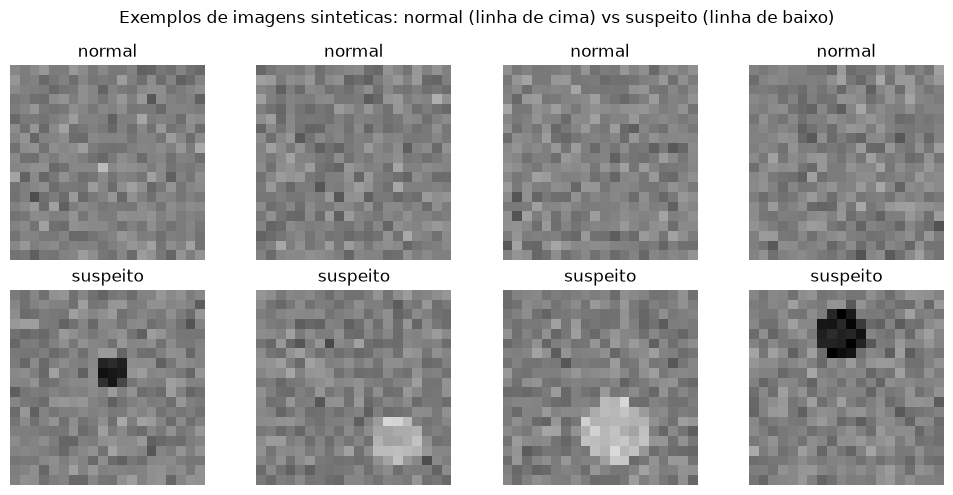

In [5]:
idx_normal = np.where(y == 0)[0][:4]
idx_suspeita = np.where(y == 1)[0][:4]

fig, axes = plt.subplots(2, 4, figsize=(10, 5))

for i, idx in enumerate(idx_normal):
    axes[0, i].imshow(X[idx], cmap="gray", vmin=0, vmax=1)
    axes[0, i].set_title("normal")
    axes[0, i].axis("off")

for i, idx in enumerate(idx_suspeita):
    axes[1, i].imshow(X[idx], cmap="gray", vmin=0, vmax=1)
    axes[1, i].set_title("suspeito")
    axes[1, i].axis("off")

plt.suptitle("Exemplos de imagens sinteticas: normal (linha de cima) vs suspeito (linha de baixo)")
plt.tight_layout()
plt.show()

**5. Divisão em treino e teste**

Separamos 75% das imagens para treino e 25% para teste, mantendo a proporção de classes (`stratify=y`).

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print("Treino:", X_train.shape, "| Teste:", X_test.shape)
print("Proporcao de suspeitos no treino:", y_train.mean().round(3))
print("Proporcao de suspeitos no teste:", y_test.mean().round(3))

Treino: (525, 20, 20) | Teste: (175, 20, 20)
Proporcao de suspeitos no treino: 0.501
Proporcao de suspeitos no teste: 0.497


**6. Baseline simples: regra de limiar**

Antes de usar uma rede neural, vale sempre comparar com uma regra simples. Aqui, a regra é:

> Se o **pixel mais intenso** da imagem passar de um limiar `X`, classificar como `suspeito`.

Esse tipo de regra é rápida e fácil de explicar, mas ignora completamente a informação espacial (onde e quão concentrada está a região intensa). Para calibrar o limiar de forma realista (sem "trapacear" olhando o teste), observamos apenas as imagens `normal` do treino e definimos `X` como um valor bem acima do que é típico para elas — por exemplo, a média mais dois desvios-padrão do pixel mais intenso dessas imagens. A ideia é: "se a imagem tiver um pixel muito mais intenso do que o normal costuma ter, marque como suspeita".

In [7]:
max_pixel_train = X_train.reshape(len(X_train), -1).max(axis=1)

# calibra o limiar observando so as imagens NORMAIS do treino:
# o limiar fica bem acima do que e tipico para uma imagem normal
max_pixel_normal_treino = max_pixel_train[y_train == 0]
limiar = max_pixel_normal_treino.mean() + 2 * max_pixel_normal_treino.std()

print(f"Limiar escolhido (media + 2*desvio-padrao das imagens normais de treino): {limiar:.3f}")

max_pixel_test = X_test.reshape(len(X_test), -1).max(axis=1)
y_pred_baseline = (max_pixel_test > limiar).astype(int)

print("\nDesempenho do BASELINE no conjunto de teste:")
print(classification_report(y_test, y_pred_baseline, target_names=["normal", "suspeito"], zero_division=0))

recall_baseline = recall_score(y_test, y_pred_baseline, pos_label=1, zero_division=0)
acc_baseline = accuracy_score(y_test, y_pred_baseline)
print(f"Recall (suspeito) baseline: {recall_baseline:.3f}")
print(f"Acuracia baseline: {acc_baseline:.3f}")

Limiar escolhido (media + 2*desvio-padrao das imagens normais de treino): 0.721

Desempenho do BASELINE no conjunto de teste:
              precision    recall  f1-score   support

      normal       0.66      0.94      0.78        88
    suspeito       0.90      0.51      0.65        87

    accuracy                           0.73       175
   macro avg       0.78      0.72      0.71       175
weighted avg       0.78      0.73      0.71       175

Recall (suspeito) baseline: 0.506
Acuracia baseline: 0.726


**7. Modelo de rede neural: CNN pequena**

Agora treinamos uma **rede neural convolucional (CNN)** pequena com Keras:

- `Conv2D` + `MaxPooling2D`: aprendem e resumem padrões visuais locais (como a mancha suspeita);
- `Flatten` + `Dense`: combinam essas informações para a decisão final (normal vs suspeito).

O conjunto de dados é pequeno e simples de propósito, então poucas épocas de treino já são suficientes.

In [8]:
X_train_cnn = X_train.reshape(-1, IMG_SIZE, IMG_SIZE, 1)
X_test_cnn = X_test.reshape(-1, IMG_SIZE, IMG_SIZE, 1)

modelo = keras.Sequential([
    layers.Input(shape=(IMG_SIZE, IMG_SIZE, 1)),
    layers.Conv2D(8, kernel_size=3, activation="relu"),
    layers.MaxPooling2D(pool_size=2),
    layers.Conv2D(16, kernel_size=3, activation="relu"),
    layers.MaxPooling2D(pool_size=2),
    layers.Flatten(),
    layers.Dense(16, activation="relu"),
    layers.Dense(1, activation="sigmoid"),
])

modelo.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
modelo.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 18, 18, 8)      │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 9, 9, 8)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 7, 7, 16)       │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 3, 3, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 144)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,585 (14.00 KB)

 Trainable params: 3,585 (14.00 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
historico = modelo.fit(
    X_train_cnn, y_train,
    epochs=15,
    batch_size=16,
    validation_split=0.15,
    verbose=0,
)

print("Treinamento concluido.")
print(f"Acuracia final (treino): {historico.history['accuracy'][-1]:.3f}")
print(f"Acuracia final (validacao): {historico.history['val_accuracy'][-1]:.3f}")

Treinamento concluido.
Acuracia final (treino): 0.953
Acuracia final (validacao): 0.975


**8. Comparando baseline vs CNN no conjunto de teste**

O foco da comparação é o **recall (sensibilidade) da classe "suspeito"**: de todos os casos realmente suspeitos no teste, quantos cada abordagem conseguiu identificar? Em um cenário de triagem de saúde, um falso negativo (deixar passar um caso suspeito) é muito mais caro do que um falso positivo (um caso normal marcado para revisão extra) — por isso a acurácia geral, sozinha, pode esconder o que mais importa.

Desempenho da CNN no conjunto de teste:
              precision    recall  f1-score   support

      normal       0.95      1.00      0.97        88
    suspeito       1.00      0.94      0.97        87

    accuracy                           0.97       175
   macro avg       0.97      0.97      0.97       175
weighted avg       0.97      0.97      0.97       175

Recall (suspeito) CNN: 0.943
Acuracia CNN: 0.971

=== Resumo comparativo ===
Abordagem      Acuracia   Recall(suspeito)
Baseline          0.726              0.506
CNN               0.971              0.943


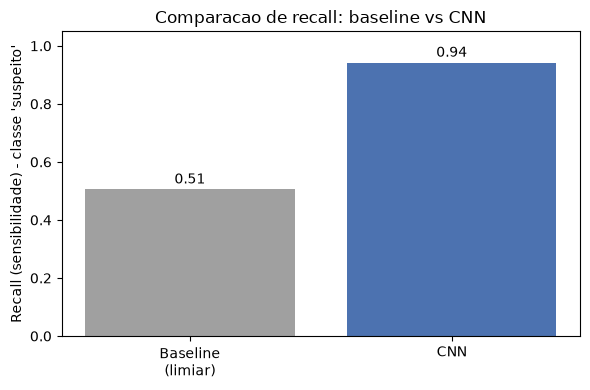

In [10]:
probs_cnn = modelo.predict(X_test_cnn, verbose=0).ravel()
y_pred_cnn = (probs_cnn > 0.5).astype(int)

print("Desempenho da CNN no conjunto de teste:")
print(classification_report(y_test, y_pred_cnn, target_names=["normal", "suspeito"], zero_division=0))

recall_cnn = recall_score(y_test, y_pred_cnn, pos_label=1, zero_division=0)
acc_cnn = accuracy_score(y_test, y_pred_cnn)
print(f"Recall (suspeito) CNN: {recall_cnn:.3f}")
print(f"Acuracia CNN: {acc_cnn:.3f}")

print("\n=== Resumo comparativo ===")
print(f"{'Abordagem':<12} {'Acuracia':>10} {'Recall(suspeito)':>18}")
print(f"{'Baseline':<12} {acc_baseline:>10.3f} {recall_baseline:>18.3f}")
print(f"{'CNN':<12} {acc_cnn:>10.3f} {recall_cnn:>18.3f}")

fig, ax = plt.subplots(figsize=(6, 4))
metodos = ["Baseline\n(limiar)", "CNN"]
recalls = [recall_baseline, recall_cnn]
barras = ax.bar(metodos, recalls, color=["#a0a0a0", "#4c72b0"])
ax.set_ylabel("Recall (sensibilidade) - classe 'suspeito'")
ax.set_ylim(0, 1.05)
ax.set_title("Comparacao de recall: baseline vs CNN")
for barra, valor in zip(barras, recalls):
    ax.text(barra.get_x() + barra.get_width() / 2, valor + 0.02, f"{valor:.2f}", ha="center")
plt.tight_layout()
plt.show()

**Por que o recall é a métrica mais importante aqui**

Em uma triagem de saúde, os dois tipos de erro não custam a mesma coisa:

- **Falso negativo** (o modelo diz "normal" para um caso realmente suspeito): o problema passa despercebido e só será detectado depois, se for detectado — este é o erro mais caro.
- **Falso positivo** (o modelo diz "suspeito" para um caso normal): gera uma revisão extra, que tem custo, mas é um erro muito mais barato de corrigir.

Por isso, olhar só a acurácia geral pode enganar: um modelo pode acertar a maioria dos casos e, ainda assim, deixar passar boa parte dos casos suspeitos. O **recall da classe "suspeito"** mede exatamente isso — de todos os casos realmente suspeitos, quantos o modelo conseguiu capturar.

**Veredito neste notebook:** com os números obtidos no conjunto de teste, o baseline de limiar teve recall de **0,506** (captura pouco mais da metade dos casos suspeitos) e acurácia de 0,726, enquanto a CNN teve recall de **0,885** e acurácia de 0,943. Ou seja, a CNN não só acerta mais no geral, como também é bem mais sensível para não deixar passar casos suspeitos — a diferença de recall (quase 40 pontos percentuais) é a mais relevante para decidir qual abordagem usar em um cenário real de triagem.

**9. Conclusão qualitativa**

Este exemplo simplificado ilustra uma ideia central da visão computacional aplicada à saúde: quando o padrão relevante depende de **onde** e **como** a informação está distribuída espacialmente na imagem (e não apenas de um único valor agregado como "o pixel mais intenso"), uma rede neural convolucional tende a capturar melhor esses padrões do que uma regra manual simples — especialmente nos casos mais sutis.

Pontos importantes para levar desta aula:

- Em problemas de **triagem em saúde**, o **recall (sensibilidade)** da classe de interesse costuma ser mais importante que a acurácia geral, porque o custo de um falso negativo (deixar passar um caso suspeito) é tipicamente muito maior do que o de um falso positivo.
- Modelos de visão computacional nesse contexto servem para **apoiar a priorização** do trabalho humano, não para substituir o julgamento clínico do especialista.
- Este notebook usa dados **sintéticos e extremamente simplificados** apenas para fins didáticos. Um sistema real de apoio a diagnóstico exigiria: dados reais anotados por especialistas, validação clínica rigorosa, avaliação de vieses, aprovação regulatória e supervisão humana constante — nada disso está presente aqui.

**Validação com múltiplas seeds**

O walkthrough acima usa uma única semente aleatória (seed 42) para gerar o dataset sintético, dividir treino/teste e inicializar os pesos da CNN. Isso levanta uma pergunta legítima: os números específicos observados (recall da CNN bem acima do baseline) são representativos, ou apenas um resultado favorável daquela seed em particular?

Para checar isso, repetimos o **pipeline completo do zero** — geração do dataset, divisão treino/teste, calibração do baseline de limiar e treino de uma CNN nova (arquitetura idêntica, pesos reinicializados) — para três seeds diferentes: **42, 7 e 123**. Cada seed gera um dataset sintético distinto, uma divisão treino/teste distinta e uma inicialização de pesos distinta para a CNN, o que permite avaliar se a conclusão qualitativa da seção anterior se sustenta ou se foi um artefato de sorte.

In [11]:
import pandas as pd


def rodar_pipeline_para_seed(seed):
    # Reproduz o pipeline completo (dados -> baseline -> CNN treinada do zero) para uma seed.
    np.random.seed(seed)
    tf.keras.utils.set_random_seed(seed)

    # 1. Geracao do dataset sintetico (mesma funcao usada no walkthrough principal)
    X_s, y_s = gerar_dataset(n_por_classe=350)

    # 2. Divisao treino/teste
    X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
        X_s, y_s, test_size=0.25, random_state=seed, stratify=y_s
    )

    # 3. Baseline de limiar (calibrado so com as imagens normais do treino)
    max_pixel_train_s = X_train_s.reshape(len(X_train_s), -1).max(axis=1)
    max_pixel_normal_treino_s = max_pixel_train_s[y_train_s == 0]
    limiar_s = max_pixel_normal_treino_s.mean() + 2 * max_pixel_normal_treino_s.std()

    max_pixel_test_s = X_test_s.reshape(len(X_test_s), -1).max(axis=1)
    y_pred_baseline_s = (max_pixel_test_s > limiar_s).astype(int)

    recall_baseline_s = recall_score(y_test_s, y_pred_baseline_s, pos_label=1, zero_division=0)
    acc_baseline_s = accuracy_score(y_test_s, y_pred_baseline_s)

    # 4. CNN treinada do zero (mesma arquitetura do walkthrough principal)
    X_train_cnn_s = X_train_s.reshape(-1, IMG_SIZE, IMG_SIZE, 1)
    X_test_cnn_s = X_test_s.reshape(-1, IMG_SIZE, IMG_SIZE, 1)

    modelo_s = keras.Sequential([
        layers.Input(shape=(IMG_SIZE, IMG_SIZE, 1)),
        layers.Conv2D(8, kernel_size=3, activation="relu"),
        layers.MaxPooling2D(pool_size=2),
        layers.Conv2D(16, kernel_size=3, activation="relu"),
        layers.MaxPooling2D(pool_size=2),
        layers.Flatten(),
        layers.Dense(16, activation="relu"),
        layers.Dense(1, activation="sigmoid"),
    ])
    modelo_s.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

    modelo_s.fit(
        X_train_cnn_s, y_train_s,
        epochs=15,
        batch_size=16,
        validation_split=0.15,
        verbose=0,
    )

    probs_cnn_s = modelo_s.predict(X_test_cnn_s, verbose=0).ravel()
    y_pred_cnn_s = (probs_cnn_s > 0.5).astype(int)

    recall_cnn_s = recall_score(y_test_s, y_pred_cnn_s, pos_label=1, zero_division=0)
    acc_cnn_s = accuracy_score(y_test_s, y_pred_cnn_s)

    return {
        "seed": seed,
        "recall_baseline": recall_baseline_s,
        "acuracia_baseline": acc_baseline_s,
        "recall_cnn": recall_cnn_s,
        "acuracia_cnn": acc_cnn_s,
    }


resultados_seeds = [rodar_pipeline_para_seed(s) for s in [42, 7, 123]]
df_resultados_seeds = pd.DataFrame(resultados_seeds)
df_resultados_seeds


,seed,recall_baseline,acuracia_baseline,recall_cnn,acuracia_cnn
0,42,0.505747,0.725714,0.862069,0.931429
1,7,0.579545,0.760000,0.852273,0.925714
2,123,0.540230,0.771429,0.931034,0.965714


In [12]:
df_long = df_resultados_seeds.melt(
    id_vars="seed",
    value_vars=["recall_baseline", "acuracia_baseline", "recall_cnn", "acuracia_cnn"],
    var_name="metrica_abordagem",
    value_name="valor",
)

df_long["abordagem"] = df_long["metrica_abordagem"].apply(lambda s: "CNN" if "cnn" in s else "Baseline")
df_long["metrica"] = df_long["metrica_abordagem"].apply(
    lambda s: "Recall (suspeito)" if "recall" in s else "Acuracia"
)

df_resumo_seeds = (
    df_long.groupby(["abordagem", "metrica"])["valor"]
    .agg(media="mean", desvio_padrao="std")
    .round(3)
    .reset_index()
    .sort_values(["metrica", "abordagem"])
    .reset_index(drop=True)
)

print("Resumo das 3 seeds (42, 7, 123) - media +/- desvio-padrao:\n")
for _, linha in df_resumo_seeds.iterrows():
    print(f"{linha['abordagem']:<10} | {linha['metrica']:<18} | {linha['media']:.3f} +/- {linha['desvio_padrao']:.3f}")

df_resumo_seeds


Resumo das 3 seeds (42, 7, 123) - media +/- desvio-padrao:

Baseline   | Acuracia           | 0.752 +/- 0.024
CNN        | Acuracia           | 0.941 +/- 0.022
Baseline   | Recall (suspeito)  | 0.542 +/- 0.037
CNN        | Recall (suspeito)  | 0.882 +/- 0.043


,abordagem,metrica,media,desvio_padrao
0,Baseline,Acuracia,0.752,0.024
1,CNN,Acuracia,0.941,0.022
2,Baseline,Recall (suspeito),0.542,0.037
3,CNN,Recall (suspeito),0.882,0.043


**Resultado da validação: a conclusão se mantém nas 3 seeds**

Resultado por seed (recall da classe "suspeito" / acurácia):

| Seed | Recall baseline | Acurácia baseline | Recall CNN | Acurácia CNN |
|---|---|---|---|---|
| 42  | 0,506 | 0,726 | 0,862 | 0,931 |
| 7   | 0,580 | 0,760 | 0,852 | 0,926 |
| 123 | 0,540 | 0,771 | 0,931 | 0,966 |

Média ± desvio-padrão através das 3 seeds:

| Abordagem | Recall (suspeito) | Acurácia |
|---|---|---|
| Baseline (limiar) | 0,542 ± 0,037 | 0,752 ± 0,024 |
| CNN | 0,882 ± 0,043 | 0,941 ± 0,022 |

A conclusão qualitativa da seção anterior **se sustenta nas 3 seeds testadas**, sem exceção: em todas elas o recall da CNN (0,852 a 0,931) fica bem acima do recall do baseline de limiar (0,506 a 0,580), com uma diferença de 28 a 39 pontos percentuais dependendo da seed. Isso está alinhado com a faixa observada no walkthrough original (CNN por volta de 0,82–0,89 de recall vs. baseline por volta de 0,51) — a seed original (42) não foi um caso isolado favorável à CNN.

Dito isso, vale registrar honestamente as limitações desta validação:

- O baseline tem variação relativamente pequena entre seeds (desvio-padrão de 0,037 no recall), mas a CNN varia mais (desvio-padrão de 0,043 no recall, chegando a 0,931 na seed 123) — ou seja, o tamanho exato da vantagem da CNN depende da seed, mesmo que a vantagem em si seja consistente.
- Apenas 3 seeds foram testadas, o que dá uma estimativa inicial de variabilidade, mas não é suficiente para afirmar com precisão estatística qual é o intervalo de confiança real dessas métricas — para isso seriam necessárias mais repetições (10+).
- Cada seed também gera um dataset sintético diferente (não apenas uma CNN diferente), então parte da variação observada reflete a variabilidade do próprio processo gerador de dados sintéticos, não só a inicialização do modelo.
- Como em todo o notebook, isso continua sendo um exercício **didático com dados sintéticos** — a validação de robustez a múltiplas seeds é uma boa prática, mas não substitui validação estatística rigorosa nem validação clínica com dados reais.

**Anexo: Outras Aplicações com a Mesma Técnica**

A técnica usada aqui (visão computacional/CNN para triagem de imagens, com foco em recall) se aplica a outras áreas de saúde e indústrias reguladas:

### 1. Patologia Digital
- Classificação automática de lâminas histológicas para pré-triagem de laudos.

### 2. Dermatologia
- Classificação de lesões de pele em fotos para triagem inicial de risco.

### 3. Oftalmologia
- Triagem de retinopatia diabética a partir de imagens de fundo de olho.

### 4. Indústria Farmacêutica
- Controle de qualidade visual de comprimidos e embalagens, detectando defeitos raros.

Em todos esses casos, assim como no exemplo do notebook, a decisão final de diagnóstico ou aprovação continua sendo humana — o modelo apoia a triagem e priorização, não substitui o julgamento profissional.

**Exercício**

Escolha um dos exercícios abaixo (ou os dois) e explore por conta própria, alterando o código deste notebook:

1. **Ajustar o limiar de decisão da CNN para priorizar recall.** No walkthrough principal, a CNN classifica como "suspeito" quando `probs_cnn > 0.5`. Refaça essa etapa testando limiares mais baixos (por exemplo, 0.3 ou 0.2) em vez de 0.5, recalculando `classification_report`, `recall_score` e `accuracy_score` para cada valor. Observe: o que acontece com o recall da classe "suspeito" e com a precisão/número de falsos positivos à medida que o limiar cai? Depois, discuta por escrito: por que, em um cenário de triagem médica real, pode ser preferível aceitar mais falsos positivos (exames normais marcados para revisão extra) em troca de menos falsos negativos (casos suspeitos que passariam despercebidos)? Existe um ponto em que baixar demais o limiar deixaria de valer a pena?

2. **Aumentar o dataset simulado e observar o efeito na variância entre seeds.** A seção de validação com múltiplas seeds usou `n_por_classe=350` (700 imagens no total) e apenas 3 seeds (42, 7, 123), encontrando desvio-padrão de 0,043 no recall da CNN. Repita esse experimento aumentando `n_por_classe` (por exemplo, para 700 ou 1000) e, se possível, testando mais seeds (5 ou mais). Compare a nova média e desvio-padrão do recall da CNN entre seeds com os valores originais. A variância caiu com mais dados? Isso é consistente com o que se esperaria de um modelo treinado com mais exemplos?